In [8]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print(f"TensorFlow 버전: {tf.__version__}")

# 유연한 설정 (피처 추가 시 INPUT_DIM만 변경)
INPUT_DIM = 2  # 현재 user_downloads_5m, z_downloads_5m
LATENT_DIM = 1
RISK_THRESHOLD = 3.0  # Z-score 기준

TensorFlow 버전: 2.11.0


In [9]:
# 더미 정상 데이터 생성 (노이즈 추가해 현실적)
np.random.seed(42)
n_samples = 1000
normal_data = np.random.normal(0, 1, (n_samples, INPUT_DIM))  # 정상 패턴

# 이상 데이터 약간 섞음 (테스트용)
anomaly_data = np.random.normal(5, 2, (50, INPUT_DIM))
data = np.vstack([normal_data, anomaly_data])
labels = np.array([0]*n_samples + [1]*50)  # 0:정상, 1:이상

# 정규화 (스케일러 피팅/변환)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 훈련/검증 분리
X_train, X_val, _, _ = train_test_split(data_scaled, labels, test_size=0.2, random_state=42)
print(f"훈련 데이터 shape: {X_train.shape}")

훈련 데이터 shape: (840, 2)


In [10]:
def build_autoencoder(input_dim, latent_dim):
    # 인코더: 입력 → latent_dim=1 병목 (정보 압축)
    encoder = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.2),  # 과적합 방지
        layers.Dense(32, activation='relu'),
        layers.Dense(latent_dim, activation='relu')  # 병목층
    ])
    
    # 디코더: latent_dim → 입력 복원
    decoder = keras.Sequential([
        layers.Dense(32, activation='relu', input_shape=(latent_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(input_dim, activation='sigmoid')  # 출력 스케일 맞춤
    ])
    
    # 전체 오토인코더
    autoencoder = keras.Sequential([encoder, decoder])
    autoencoder.compile(optimizer='adam', loss='mse')  # 재구성 오차 최소화
    
    return autoencoder, encoder, decoder

# 모델 생성
model, encoder, decoder = build_autoencoder(INPUT_DIM, LATENT_DIM)
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (None, 1)                 2305      
                                                                 
 sequential_4 (Sequential)   (None, 2)                 2306      
                                                                 
Total params: 4,611
Trainable params: 4,611
Non-trainable params: 0
_________________________________________________________________


Epoch 1/50
27/27 [==============================] - 1s 8ms/step - loss: 1.1864 - val_loss: 1.1353
Epoch 2/50
27/27 [==============================] - 0s 3ms/step - loss: 0.9545 - val_loss: 0.9255
Epoch 3/50
27/27 [==============================] - 0s 3ms/step - loss: 0.8363 - val_loss: 0.8925
Epoch 4/50
27/27 [==============================] - 0s 3ms/step - loss: 0.8148 - val_loss: 0.8746
Epoch 5/50
27/27 [==============================] - 0s 3ms/step - loss: 0.8008 - val_loss: 0.8625
Epoch 6/50
27/27 [==============================] - 0s 3ms/step - loss: 0.7930 - val_loss: 0.8544
Epoch 7/50
27/27 [==============================] - 0s 3ms/step - loss: 0.7861 - val_loss: 0.8453
Epoch 8/50
27/27 [==============================] - 0s 3ms/step - loss: 0.7774 - val_loss: 0.8343
Epoch 9/50
27/27 [==============================] - 0s 3ms/step - loss: 0.7678 - val_loss: 0.8213
Epoch 10/50
27/27 [==============================] - 0s 3ms/step - loss: 0.7601 - val_loss: 0.8083
Epoch 11/50
27/27 [

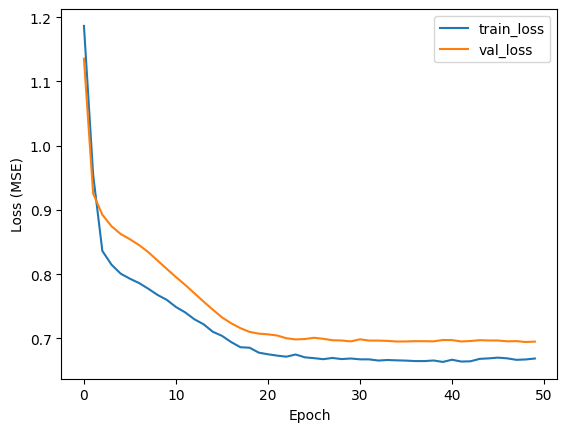

In [11]:
history = model.fit(
    X_train, X_train,  # 입력=출력 (재구성 학습)
    epochs=50,
    batch_size=32,
    validation_data=(X_val, X_val),
    verbose=1
)

# 손실 그래프
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


7/7 [==============================] - 0s 2ms/step


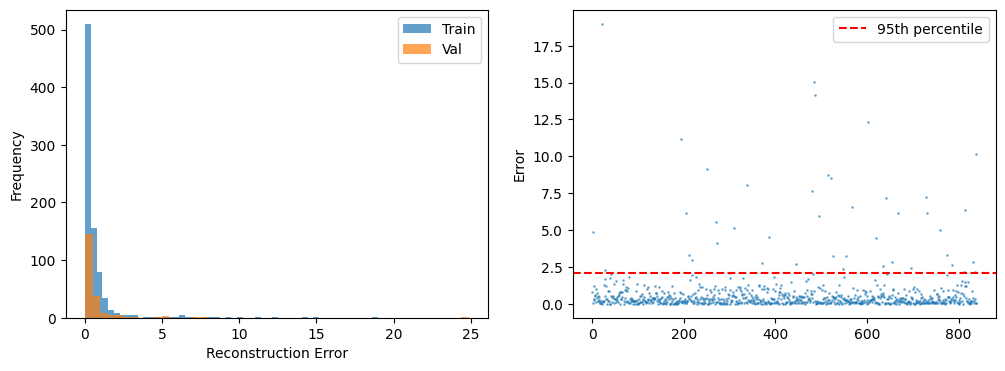

Train error stats: mean=0.6661, std=1.5522
95th percentile threshold: 2.0558


In [12]:
# 재구성 오차 계산
def compute_recon_error(model, data):
    recon = model.predict(data)
    return np.mean((data - recon)**2, axis=1)

train_errors = compute_recon_error(model, X_train)
val_errors = compute_recon_error(model, X_val)

# 오차 분포 시각화
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.hist(train_errors, bins=50, alpha=0.7, label='Train')
plt.hist(val_errors, bins=50, alpha=0.7, label='Val')
plt.xlabel('Reconstruction Error'); plt.ylabel('Frequency'); plt.legend()

plt.subplot(122)
plt.scatter(range(len(train_errors)), train_errors, alpha=0.5, s=1)
plt.axhline(np.percentile(train_errors, 95), color='r', linestyle='--', label='95th percentile')
plt.ylabel('Error'); plt.legend()
plt.show()

print(f"Train error stats: mean={train_errors.mean():.4f}, std={train_errors.std():.4f}")
print(f"95th percentile threshold: {np.percentile(train_errors, 95):.4f}")

2/2 [==============================] - 0s 3ms/step
Anomaly detection rate: 98.0%
False positive rate: 2.0%
Anomaly errors mean: 17.9765


/var/tmp/ipykernel_4710/242326600.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal_test_errors, anomaly_errors], labels=['Normal', 'Anomaly'])


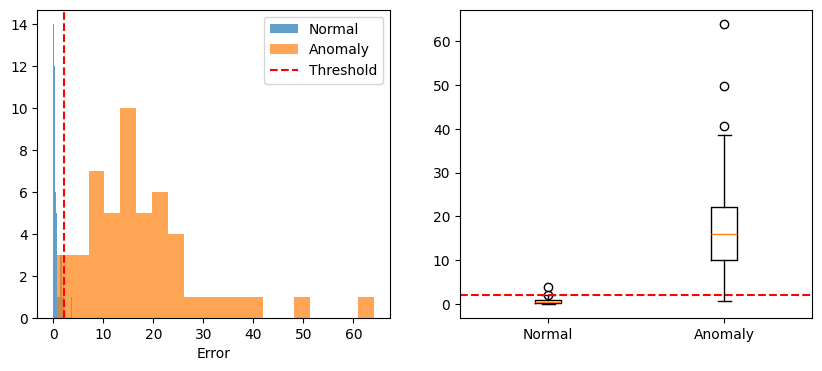

In [13]:
# 테스트: 이상 데이터 재구성 오차
anomaly_errors = compute_recon_error(model, anomaly_data)  # 2단계 생성 데이터
normal_test_errors = compute_recon_error(model, normal_data[:50])  # 정상 샘플

# 탐지 결과
threshold = np.percentile(train_errors, 95)
anomaly_detected = np.mean(anomaly_errors > threshold)
normal_detected = np.mean(normal_test_errors > threshold)

print(f"Anomaly detection rate: {anomaly_detected:.1%}")
print(f"False positive rate: {normal_detected:.1%}")
print(f"Anomaly errors mean: {anomaly_errors.mean():.4f}")

# 시각화
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.hist(normal_test_errors, bins=20, alpha=0.7, label='Normal')
plt.hist(anomaly_errors, bins=20, alpha=0.7, label='Anomaly')
plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
plt.legend(); plt.xlabel('Error')

plt.subplot(122)
plt.boxplot([normal_test_errors, anomaly_errors], labels=['Normal', 'Anomaly'])
plt.axhline(threshold, color='r', linestyle='--')
plt.show()


In [15]:
def compute_risk_improved(errors, threshold, risk_scale=20):
    """개선: threshold 초과 시 100, 미만 시 0-99 정수 스코어"""
    z_scores = np.abs((errors - errors.mean()) / (errors.std() + 1e-6))
    continuous_risk = np.clip(z_scores * risk_scale, 0, 99).astype(int)
    binary_risk = (errors > threshold).astype(int) * 100
    return np.maximum(continuous_risk, binary_risk)

# 재테스트
all_errors = np.concatenate([train_errors, val_errors, normal_test_errors, anomaly_errors])
risk_improved = compute_risk_improved(all_errors, threshold)
print("개선된 risk 예시:", risk_improved[:10])
print("High risk:", risk_improved[np.argsort(risk_improved)[-5:]])
print("Risk 분포:\n", np.bincount(risk_improved.astype(int), minlength=101))


개선된 risk 예시: [  2 100   6   4   0   4   3   3   5   1]
High risk: [100 100 100 100 100]
Risk 분포:
 [ 45  52  84  99 211 352 200   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0 107]
